In [68]:
import earthaccess
import os
import warnings
import csv
from osgeo import gdal
import numpy as np
import math
import rasterio as rio
import xarray as xr
import holoviews as hv
import hvplot.xarray
import netCDF4 as nc
#import cv2 as cv

import glob
import sys
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import rasterio
from rasterio.transform import Affine
from scipy import linalg
from lxml import etree
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
from skimage.transform import hough_line, hough_line_peaks

wav_min = 418
wav_max = 492
bin_size = 1
polydeg = 3
sys.path.append('../')
import EMIT_NOX
import BATCH_RETR
import importlib

# Reload the module
importlib.reload(EMIT_NOX)
importlib.reload(BATCH_RETR)

crop_about_loc = EMIT_NOX.crop_about_loc
multipass_retrieval = BATCH_RETR.multipass_retrieval

from config import CONFIG, POWER_PLANTS, CROSS_SECTIONS, LOCS
sys.path.append('../../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr
help(emit_xarray)

Help on function emit_xarray in module emit_tools:

emit_xarray(filepath, ortho=False, qmask=None, unpacked_bmask=None)
    This function utilizes other functions in this module to streamline opening an EMIT dataset as an xarray.Dataset.
    
    Parameters:
    filepath: a filepath to an EMIT netCDF file
    ortho: True or False, whether to orthorectify the dataset or leave in crosstrack/downtrack coordinates.
    qmask: a numpy array output from the quality_mask function used to mask pixels based on quality flags selected in that function. Any non-orthorectified array with the proper crosstrack and downtrack dimensions can also be used.
    unpacked_bmask: a numpy array from  the band_mask function that can be used to mask band-specific pixels that have been interpolated.
    
    Returns:
    out_xr: an xarray.Dataset constructed based on the parameters provided.



In [69]:
POWER_PLANTS

{'New_Madrid_Power_Plant': {'LON': -89.5617,
  'LAT': 36.5147,
  'NOx Mass (short tons)': 8040.59,
  'State': 'MO',
  'Fac_ID': 2167},
 'Limestone': {'LON': -96.2525,
  'LAT': 31.4219,
  'NOx Mass (short tons)': 4804.775,
  'State': 'TX',
  'Fac_ID': 298},
 'Fort_Martin_Power_Station': {'LON': -79.9275,
  'LAT': 39.7107,
  'NOx Mass (short tons)': 4385.661,
  'State': 'WV',
  'Fac_ID': 3943},
 'Ninemile_Point': {'LON': -90.1458,
  'LAT': 29.9472,
  'NOx Mass (short tons)': 4279.572,
  'State': 'LA',
  'Fac_ID': 1403},
 'Scherer': {'LON': -83.8072,
  'LAT': 33.0583,
  'NOx Mass (short tons)': 4276.264,
  'State': 'GA',
  'Fac_ID': 6257},
 'Ghent': {'LON': -85.035,
  'LAT': 38.7497,
  'NOx Mass (short tons)': 4121.132,
  'State': 'KY',
  'Fac_ID': 1356},
 'Miami_Fort_Power_Station': {'LON': -84.8031,
  'LAT': 39.1131,
  'NOx Mass (short tons)': 4075.405,
  'State': 'OH',
  'Fac_ID': 2832},
 'Hunter': {'LON': -111.0289,
  'LAT': 39.1747,
  'NOx Mass (short tons)': 4033.598,
  'State': 'UT

In [121]:
target_name = 'Limestone'
samples = glob.glob(f"{CONFIG['data_folder']}/{target_name}/*_RAD_*.nc")
# samples = [samples[1]]
# ds = emit_xarray(samples[1])
# plt.imshow(ds['radiance'][:,:,0])

dSCDs, masks, lats, lons, s = multipass_retrieval(target_name, samples)

Starting /Volumes/T9/EMIT-NOX/data/EMIT/Limestone/EMIT_L1B_RAD_001_20240128T191214_2402813_012.nc...
NOX cross section created! Computing DOAS0...
Found DOAS0! Computing plume mask...
Found plume mask! Computing DOAS...
DOAS Retrieval done!
Starting /Volumes/T9/EMIT-NOX/data/EMIT/Limestone/EMIT_L1B_RAD_001_20240728T190709_2421013_014.nc...
NOX cross section created! Computing DOAS0...
Found DOAS0! Computing plume mask...
Found plume mask! Computing DOAS...
DOAS Retrieval done!
Starting /Volumes/T9/EMIT-NOX/data/EMIT/Limestone/EMIT_L1B_RAD_001_20241201T171550_2433612_020.nc...
NOX cross section created! Computing DOAS0...
Found DOAS0! Computing plume mask...
Found plume mask! Computing DOAS...
DOAS Retrieval done!
Starting /Volumes/T9/EMIT-NOX/data/EMIT/Limestone/EMIT_L1B_RAD_001_20241201T171602_2433612_021.nc...
NOX cross section created! Computing DOAS0...
Found DOAS0! Computing plume mask...
Found plume mask! Computing DOAS...
DOAS Retrieval done!
Starting /Volumes/T9/EMIT-NOX/data/E

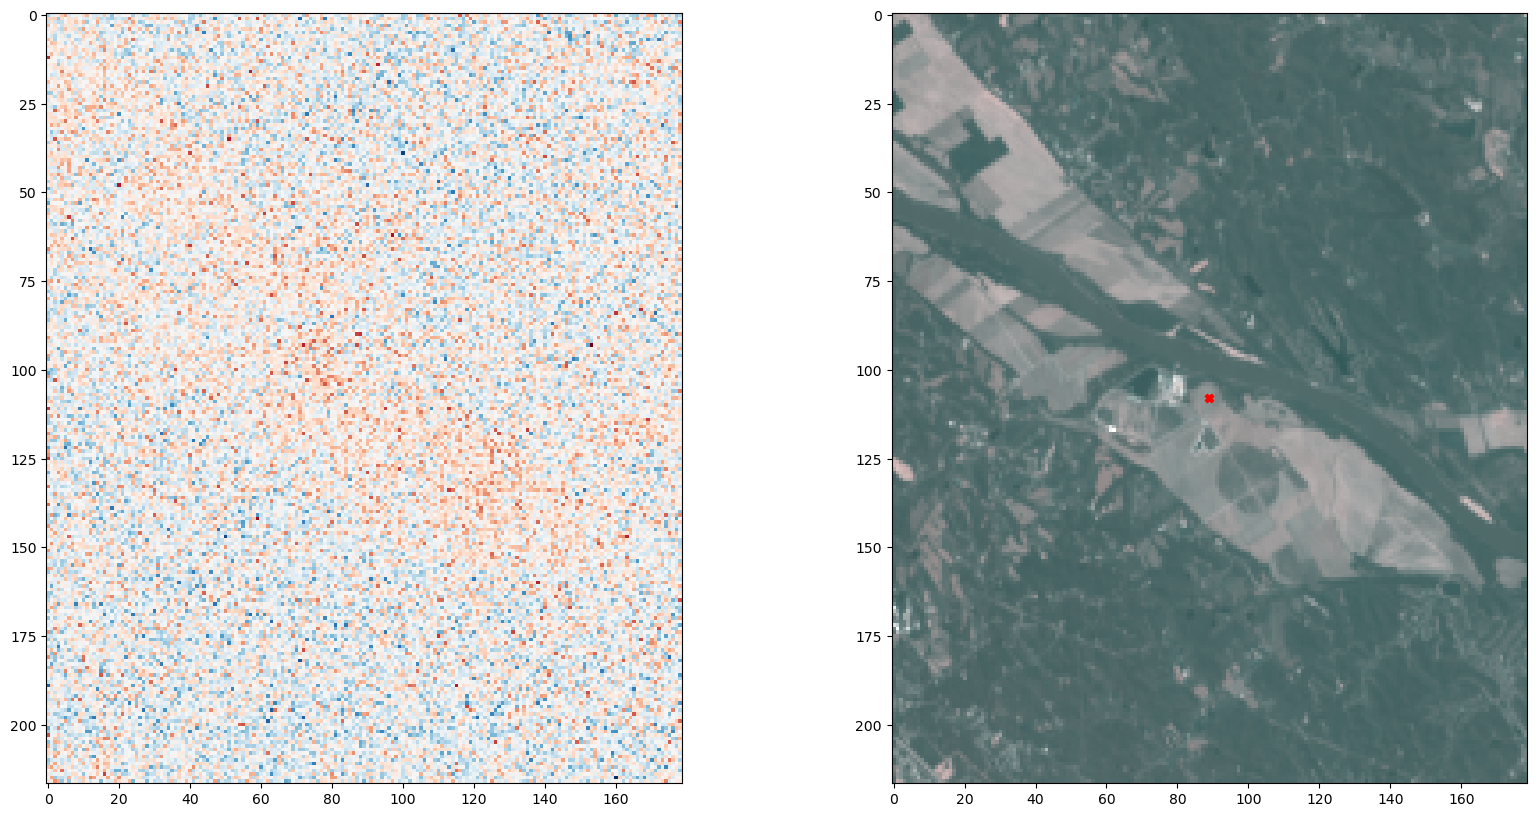

In [120]:
sample_idx = np.random.randint(0, len(samples))

ds = emit_xarray(samples[sample_idx], ortho=False)
ys, xs = np.where(~np.isnan(dSCDs[sample_idx]))
if len(ys) == 0:
    raise ValueError("No pixels found inside requested box!")

y0, y1 = ys.min(), ys.max()
x0, x1 = xs.min(), xs.max()


rad_window = ds['radiance'][y0:y1+1, x0:x1+1, :]

def get_idxs(wls, val, offset=20):
    minpoint = np.argmin(np.abs(np.array(wls)-val+offset))
    maxpoint = np.argmin(np.abs(np.array(wls)-val-offset))
    return [minpoint,maxpoint]
    
r_bounds = get_idxs(ds['wavelengths'], 610)
g_bounds = get_idxs(ds['wavelengths'], 555)
b_bounds = get_idxs(ds['wavelengths'], 465)

r_img = np.mean(rad_window[:,:,r_bounds[0]:r_bounds[1]+1], axis=2)
b_img = np.mean(rad_window[:,:,b_bounds[0]:g_bounds[1]+1], axis=2)
g_img = np.mean(rad_window[:,:,b_bounds[0]:g_bounds[1]+1], axis=2)

rgbimg = np.stack([r_img/np.max(r_img), g_img/np.max(g_img), b_img/np.max(b_img)], axis=2)

fig, axs = plt.subplots(1,2,figsize=(20,10))
axs[0].imshow(dSCDs[sample_idx][y0:y1+1, x0:x1+1], cmap='RdBu_r')
axs[1].imshow(rgbimg)
axs[1].scatter([len(rgbimg[0])//2], [len(rgbimg)//2], c='red', marker='X')

In [103]:
imgs = []
for i in dSCDs:
    if i is None:
        continue
    ys, xs = np.where(~np.isnan(i))

    # This should never ever happen
    if len(ys) == 0:
        raise ValueError("No pixels found inside requested box!")
    
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    newimg = i[y0:y1+1, x0:x1+1]
    if newimg.shape[0] < 218:
        continue
    imgs.append(newimg)
    print(imgs[-1].shape)

H = max(im.shape[0] for im in imgs)
W = max(im.shape[1] for im in imgs)
def pad_to_center(img, H, W):
    h, w = img.shape

    # amount to pad on each side
    pad_top    = (H - h) // 2
    pad_bottom = H - h - pad_top
    pad_left   = (W - w) // 2
    pad_right  = W - w - pad_left

    return np.pad(img,
                  ((pad_top, pad_bottom), (pad_left, pad_right)),
                  mode='constant', constant_values=np.nan)
imgs_padded = [pad_to_center(im, H, W) for im in imgs]
for i in imgs_padded: print(f'padded {i.shape}')

(219, 144)
(221, 214)
(221, 216)
(220, 171)
(222, 129)
(219, 187)
(220, 213)
(219, 135)
(222, 213)
(221, 217)
(222, 214)
(219, 213)
(218, 215)
(222, 215)
(221, 213)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)
padded (222, 217)


In [104]:
stack = np.stack(imgs_padded, axis=0)   # shape → (N, H, W)
median_img = np.nanmedian(stack, axis=0)
mad_img = np.nanmedian(np.abs(stack - median_img), axis=0)

/var/folders/2s/hcpwpvzx2l91_2cn_jqj0r140000gn/T/ipykernel_41036/1118254452.py:2: RuntimeWarning: All-NaN slice encountered
  median_img = np.nanmedian(stack, axis=0)
/var/folders/2s/hcpwpvzx2l91_2cn_jqj0r140000gn/T/ipykernel_41036/1118254452.py:3: RuntimeWarning: All-NaN slice encountered
  mad_img = np.nanmedian(np.abs(stack - median_img), axis=0)


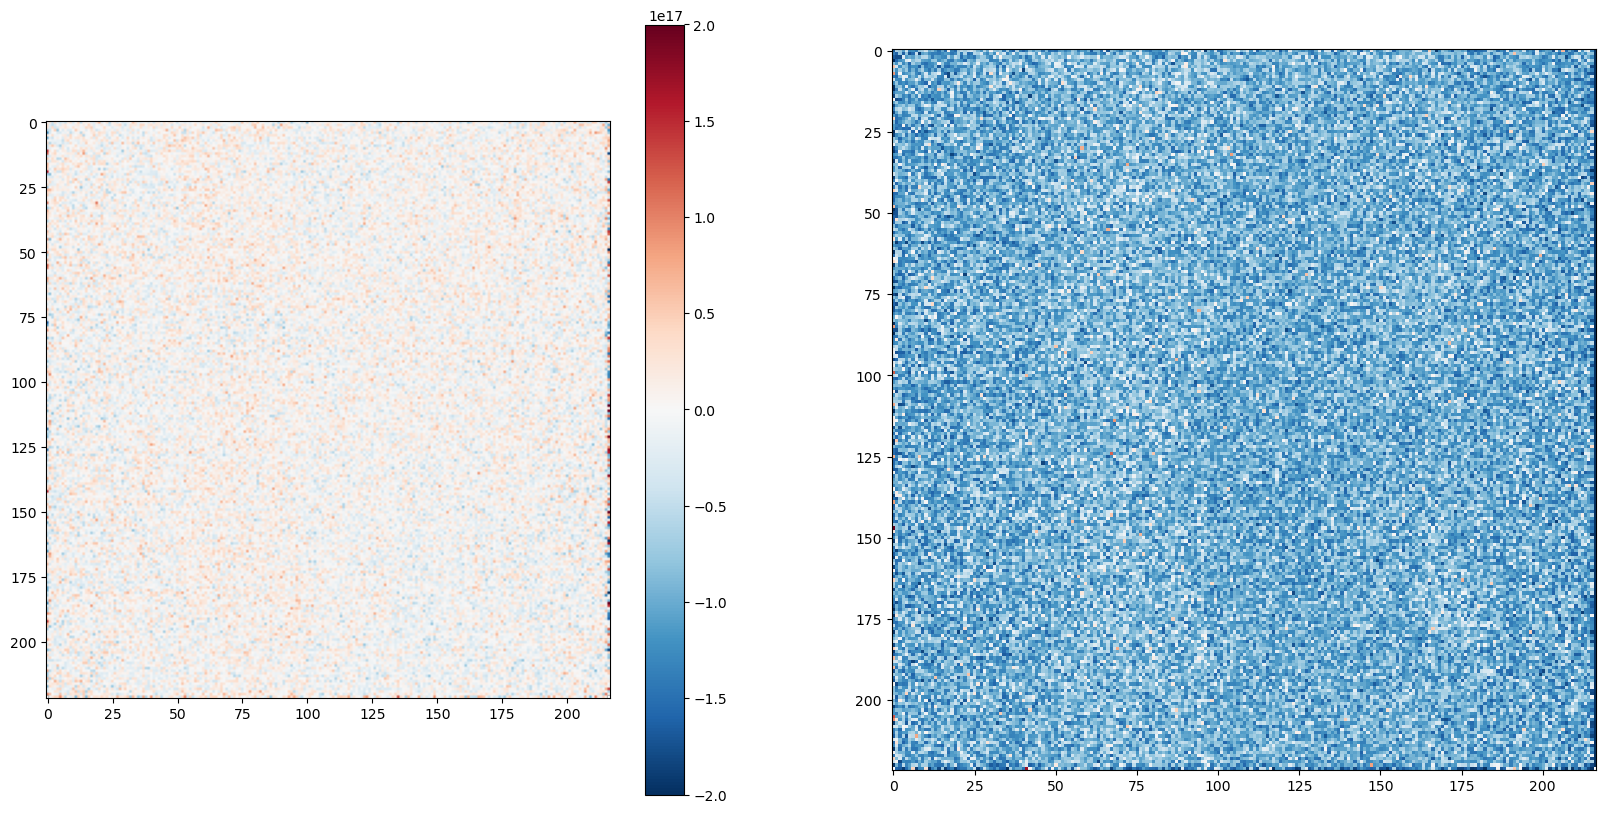

In [105]:
fig, axs = plt.subplots(1,2, figsize=(20,10))
im = axs[0].imshow(median_img*1e19, cmap='RdBu_r', vmin=-2e17, vmax=2e17)
plt.colorbar(im, ax=axs[0])
axs[1].imshow(mad_img, cmap='RdBu_r')

In [ ]:
clat, clon = POWER_PLANTS[target_name]['LAT'], POWER_PLANTS[target_name]['LON']
mask = crop_about_loc(ds, clat=clat, clon=clon, km_boundary=10)
plt.imshow(ds['radiance'][:,:,0])

In [12]:
imfns = glob.glob(f"{CONFIG['data_folder']}/RIYADH_PLANT_9/*RAD*")
# fn = '/Volumes/T9/EMIT-NOX/data/EMIT/LOC_24.732_46.704/EMIT_L1B_RAD_001_20220903T051912_2224604_012.nc'
print(len(imfns))
fn = imfns[-1]
# fn = '/Volumes/T9/EMIT-NOX/data/EMIT/LOC_33.942_-118.404/EMIT_L1B_RAD_001_20220828T174405_2224012_007.nc'
# fn = '/Volumes/T9/EMIT-NOX/data/EMIT/LOC_33.942_-118.404/EMIT_L1B_RAD_001_20230728T214106_2320914_002.nc'
# # fn = '/Volumes/T9/EMIT-NOX/data/EMIT/XAI_CENTER/EMIT_L1B_RAD_001_20240330T183753_2409012_022.nc'
ds = emit_xarray(fn)
fn

17


'/Volumes/T9/EMIT-NOX/data/EMIT/RIYADH_PLANT_9/EMIT_L1B_RAD_001_20250730T075549_2521105_014.nc'

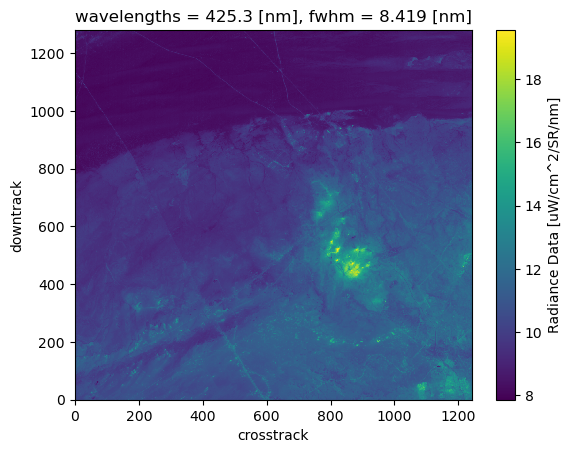

In [13]:

def gaussian_kernel(x, mu, fwhm_nm):
    """
    Create normalized Gaussian kernel with standard deviation sigma (nm) based on sigma = FWHM/sqrt(2log2)
    """
    # Define standard deviation sigma
    sigma = fwhm_nm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    # Create kernel
    k = np.exp(-0.5 * ((x - mu) / sigma)**2)
    # Normalize kernel to area = 1
    k /= np.trapz(k, x, dx=0.01)
    return k

def convolve_to_sensor_grid(xs_wav_nm, xs, sensor_wav_nm, sensor_fwhm_nm):
    """
    Convolve high-res cross-section xs_sigma(xs_wav_nm) to sensor grid using per-band Gaussian SRF.
    Returns array of length len(sensor_wav_nm).
    """
    out = np.zeros_like(sensor_wav_nm, dtype=float)
    for i, (mu, fwhm) in enumerate(zip(sensor_wav_nm, sensor_fwhm_nm)):
        # Create normalized Gaussian kernel
        k = gaussian_kernel(xs_wav_nm, mu, fwhm)
        # Apply kernel to absorption cross-section spectrum
        out[i] = np.trapz(k * xs, xs_wav_nm, dx=0.01)
    return out
    
# Get NO2 absorption cross-sections @ 220K from Vandaele et al. (1998)
# Following TROPOMI NO2 ATBD: https://sentinel.esa.int/documents/247904/2476257/sentinel-5p-tropomi-atbd-no2-data-products
# Data reference: http://spectrolab.aeronomie.be/no2.htm
no2_cross_sections_path = CROSS_SECTIONS['NOX']
no2_cross_sections = pd.read_csv(
    no2_cross_sections_path,
    sep=" ",
    usecols=[3, 4],
    names=["vacuum_wavenumber_cm-1", "cross_section_cm^2/molecule_@220K"],
)
# add wavelength column (nm)
no2_cross_sections["vacuum_wavelength_nm"] = 1e7 / no2_cross_sections["vacuum_wavenumber_cm-1"].values

emit_spec_wlen = ds["wavelengths"].to_numpy().astype(np.float64)
emit_spec_fwhm = ds["fwhm"].to_numpy().astype(np.float64)

no2_cross_sections_conv = convolve_to_sensor_grid(no2_cross_sections["vacuum_wavelength_nm"], 
                                                  no2_cross_sections["cross_section_cm^2/molecule_@220K"],
                                                  emit_spec_wlen,
                                                  emit_spec_fwhm)

# Select bands and convolved cross-sections in fitting window
window_sel = (emit_spec_wlen >= wav_min) & (emit_spec_wlen <= wav_max)
emit_vnir_spectral_bands_fitting_window = emit_spec_wlen[window_sel].copy()
no2_cross_sections_conv_fitting_window = no2_cross_sections_conv[window_sel].copy()

desired_bands = emit_vnir_spectral_bands_fitting_window
desired_bands

ds.sel(wavelengths=desired_bands[0], method='nearest')['radiance'].plot()

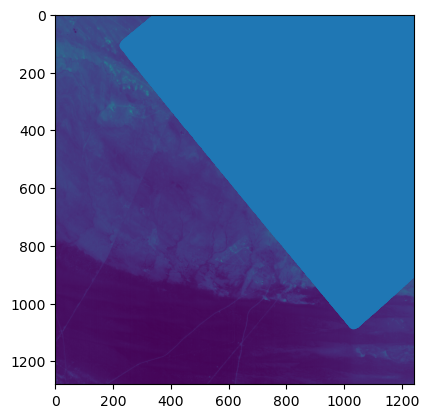

In [59]:
plt.imshow(ds['radiance'][:,:,0])

plt.scatter(xs, ys)

In [27]:
lat = ds["lat"].values     # shape (DT, CT)
lon = ds["lon"].values

In [74]:
# Process crop2loc
locdata = LOCS['RIYADH_PLANT_9']

area_km = 10

dlat = (area_km/2)/111
dlon = (area_km/2)/(111*np.cos(np.radians(locdata['LAT'])))

lat_min = locdata['LAT'] - dlat
lat_max = locdata['LAT'] + dlat
lon_min = locdata['LON'] - dlon
lon_max = locdata['LON'] + dlon

mask = (
    (lat >= lat_min) & (lat <= lat_max) &
    (lon >= lon_min) & (lon <= lon_max)
)

ys, xs = np.where(mask)

print(ys, xs)

if len(ys) == 0:
    raise ValueError("No pixels found inside requested box!")

y0, y1 = ys.min(), ys.max()
x0, x1 = xs.min(), xs.max()

cube_crop = ds["radiance"][y0:y1+1, x0:x1+1, :]
cube_crop.shape

[ 77  78  78 ... 296 296 297] [1112 1111 1112 ... 1095 1096 1094]


(221, 214, 285)

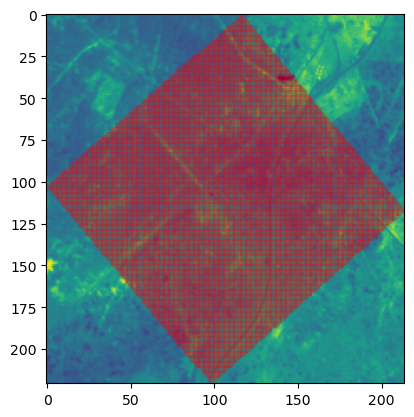

In [75]:
plt.imshow(cube_crop[:,:,0], origin="upper")
plt.scatter(xs - x0, ys - y0, s=1, c='red', alpha=0.2)
plt.show()

In [53]:
ys-y0

array([   0,    0,    0, ..., 1069, 1069, 1070])

In [19]:
locdata

{'LAT': 24.95005929724472, 'LON': 47.065018186187366}